# 과제 1 · 전처리 실습 (5주차 · 2026. 9. 28.)

기초지질데이터과학 · **제출: 오늘 23:59, LMS 과제 1 — 이 노트북(.ipynb) 파일 하나** · 배점 5 (코드 작동 2 · 해석 2 · 기록지 1)

**이름:**　김태연　　**학번:** 202001192

- 쓰는 파일: `sandstone_density.csv`, `eq_catalog_korea_2006_2025.csv` — 왼쪽 📁 파일 창에 끌어다 놓으세요.
- 두 자료는 **교육용 합성 자료**입니다. 기상청·USGS 목록의 형식을 본떴고 함정을 일부러 심었습니다. 큰 지진 몇 개(경주 2016, 포항 2017 등)는 실제 사건의 날짜와 규모를 따랐지만 시각·위치는 근사값입니다.
- AI는 자유롭게 씁니다. 쓴 것은 맨 아래 **기록지**에 적습니다. 검증 없는 제출은 해석 0점입니다.

In [ ]:
# from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# drive.mount('/content/drive')

# PROJECT_DIR = Path(
#     '/content/drive/Othercomputers/'
#     '내 컴퓨터/'
#     '직박이구리/'
#     '기초지질데이터과학'
# )

# WORKDIR = next(folder for folder in PROJECT_DIR.iterdir()
#                if folder.name.startswith('5'))

# os.chdir(WORKDIR)
# print(f'작업 폴더 연결 완료: {Path.cwd()}')

# dfkdf

## Part A · 사암 밀도 — 3σ와 MAD (약 15분)

같은 사암층에서 나흘에 걸쳐 시료 40개의 겉보기 밀도를 쟀습니다. 기록 규칙은 **g/cm³** 였습니다. 강의 94쪽·109–113쪽과 같은 상황입니다.

In [22]:
sd = pd.read_csv("sandstone_density.csv")
print(sd["밀도"].describe())
sd

count      40.000000
mean      265.531000
std       796.438345
min      -999.000000
25%         2.290000
50%         2.320000
75%         2.370000
max      2400.000000
Name: 밀도, dtype: float64


,시료번호,채취일,기재자,밀도,비고
0,SD-01,2025-10-02,A,2.30,NaN
1,SD-02,2025-10-02,A,2.29,NaN
2,SD-03,2025-10-02,A,2.38,NaN
3,SD-04,2025-10-02,A,2.28,엽리 약함
4,SD-05,2025-10-02,A,2.29,NaN
5,SD-06,2025-10-02,A,2.37,NaN
6,SD-07,2025-10-02,A,2.29,NaN
7,SD-08,2025-10-02,A,-999.00,"시료 파손, 측정 못 함"
8,SD-09,2025-10-02,A,2.34,NaN
9,SD-10,2025-10-02,A,2.32,NaN


**A-1.** AI에게 아래처럼 요청하고, 받은 코드를 다음 칸에 붙여 넣어 실행하세요. **몇 개가 걸렸나요?**

> pandas 데이터프레임 `sd`의 `밀도` 열에서 평균과 표준편차로 z-점수를 구해, |z| > 3인 행을 이상치로 골라 보여 주는 코드를 짜 줘.

In [23]:
# 평균과 표준편차 계산
mean_density = sd["밀도"].mean()
std_density = sd["밀도"].std()

# z-점수 계산
z_score = (sd["밀도"] - mean_density) / std_density

# |z| > 3인 이상치 행 필터링
outliers = sd[z_score.abs() > 3]
outliers

,시료번호,채취일,기재자,밀도,비고


 이상치가 하나도 걸리지 않음.

**A-2.** 중앙값과 MAD로 바꿔 보세요(강의 110–113쪽). 로버스트 z = (x − 중앙값) / (1.4826 × MAD), |z| > 3이면 **후보**입니다. 직접 짜도, AI에게 시켜도 됩니다. **몇 개가 걸렸나요?**

In [24]:
# 중앙값(Median) 및 MAD(Median Absolute Deviation) 계산
median_val = sd["밀도"].median()
mad_val = (sd["밀도"] - median_val).abs().median()

# 로버스트 z-점수 계산
robust_z = (sd["밀도"] - median_val) / (1.4826 * mad_val)

# |z| > 3 조건으로 이상치 후보 필터링
outliers_robust = sd[robust_z.abs() > 3]
outliers_robust

,시료번호,채취일,기재자,밀도,비고
7,SD-08,2025-10-02,A,-999.00,"시료 파손, 측정 못 함"
11,SD-12,2025-10-03,B,23.10,NaN
16,SD-17,2025-10-03,B,2.05,"풍화 심함, 손으로 부서짐"
20,SD-21,2025-10-09,C,2220.00,NaN
21,SD-22,2025-10-09,C,2400.00,NaN
22,SD-23,2025-10-09,C,2310.00,NaN
23,SD-24,2025-10-09,C,2270.00,NaN
24,SD-25,2025-10-09,C,2320.00,NaN
26,SD-27,2025-10-09,C,3.22,NaN
32,SD-33,2025-10-10,D,2.58,"석영 교결, 매우 단단함"


이상치가  10 개 걸림

**A-3.** 걸린 값마다 **고침 / 뺌(NaN) / 남김** 중 하나로 정하세요. 근거는 자료 **밖**에서 옵니다 — 비고, 단위 규칙, 사암 밀도의 물리적 범위(대략 2.0–2.6 g/cm³ · 석영 2.65, 방해석 2.71보다 클 수 없음).

| 시료번호 | 값 | 결정 | 근거 |
|---|---|---|---|
| **SD-08** | -999.00 | **뺌 (NaN)** | 비고에 '시료 파손, 측정 못 함'이라 기재되어 있음. |
| **SD-12** | 23.10 | **고침 (2.31)** | 정상 범위를 소수점 한 자리만큼 벗어났으며, 소수점 위치 오타로 판단 |
| **SD-17** | 2.05 | **남김** | 비고에 '풍화 심함'으로 기록되어 있으며, 풍화가 심한 사암의 경우 밀도가 2.05 g/cm³까지 낮아질 수 있는 물리적 범위 내의 값이므로 유지 |
| **SD-21** | 2220.00 | **고침 (2.22)** | 기록 단위 규칙(g/cm³) 대신 kg/m³ 단위로 잘못 기재된 오기입으로 판단 |
| **SD-22** | 2400.00 | **고침 (2.40)** | kg/m³ 단위 오기입으로 판단 |
| **SD-23** | 2310.00 | **고침 (2.31)** | kg/m³ 단위 오기입으로 판단 |
| **SD-24** | 2270.00 | **고침 (2.27)** | kg/m³ 단위 오기입으로 판단 |
| **SD-25** | 2320.00 | **고침 (2.32)** | kg/m³ 단위 오기입으로 판단 |
| **SD-27** | 3.22 | **뺌 (NaN)** | 사암의 주 구성 광물인 석영(2.65 g/cm³)이나 방해석(2.71 g/cm³)의 밀도를 초과하는 값임 |
| **SD-33** | 2.58 | **남김** | 비고에 '석영 교결, 매우 단단함'으로 기록되어 있으며, 석영의 이론적 한계 밀도(2.65 g/cm³) 이내이므로 유지. |

**3σ가 A-1에서 놓친 이유 (한 문장):** 극단적인 입력 오류 값들(-999.00 및 2400.00 등)이 평균과 표준편차에 반영되어 평균과 표준편차 값을 뒤틀어 정상범위 안으로 들어오게 됨.

In [25]:
# A-3: 결정대로 고친 사본을 만들고, 정제 전후를 비교하세요
sd_clean = sd.copy()

# 1. 뺌 (NaN 처리)
sd_clean.loc[sd_clean["시료번호"] == "SD-08", "밀도"] = np.nan
sd_clean.loc[sd_clean["시료번호"] == "SD-27", "밀도"] = np.nan

# 2. 고침 (단위 및 오타 수정)
sd_clean.loc[sd_clean["시료번호"] == "SD-12", "밀도"] = 2.31
sd_clean.loc[sd_clean["시료번호"] == "SD-21", "밀도"] = 2.22
sd_clean.loc[sd_clean["시료번호"] == "SD-22", "밀도"] = 2.40
sd_clean.loc[sd_clean["시료번호"] == "SD-23", "밀도"] = 2.31
sd_clean.loc[sd_clean["시료번호"] == "SD-24", "밀도"] = 2.27
sd_clean.loc[sd_clean["시료번호"] == "SD-25", "밀도"] = 2.32

# 3. 남김 (SD-17, SD-33은 변경 없이 원래 값 유지)

print("정제 전  평균 %.3f  중앙값 %.3f  (n=%d)" % (sd["밀도"].mean(), sd["밀도"].median(), sd["밀도"].notna().sum()))
print("정제 후  평균 %.3f  중앙값 %.3f  (n=%d)" % (sd_clean["밀도"].mean(), sd_clean["밀도"].median(), sd_clean["밀도"].notna().sum()))

정제 전  평균 265.531  중앙값 2.320  (n=40)
정제 후  평균 2.309  중앙값 2.310  (n=38)


## Part B · 지진 목록 — 무엇을 남기고 무엇을 뺄까 (약 45분)

**질문 (주어짐):** 2006–2025년 한반도에서 **규모 5.0 이상 지진은 몇 번** 있었고, **b값**은 얼마인가?

**먼저 예상하세요 — 자료를 보기 전에.** 여러분은 경주(2016, M5.8)와 포항(2017, M5.4)을 압니다. 명세서 ① 5번에 따르면 b값은 보통 0.8–1.2입니다.
예상: 규모 5 이상 _3_ 번 · b값 _0.9__

명세서 ① (지진 카탈로그)의 **3. 알려진 함정**을 옆에 펴 두세요. b값은 아래 `report()`가 Mc = 2.1(2016년 이전 관측망에서도 빠짐없이 잡히는 규모)로 계산합니다.

In [26]:
eq = pd.read_csv("eq_catalog_korea_2006_2025.csv")

def b_value(m, Mc=2.1, dM=0.1):
    # b값 최우추정 (Aki 1965, Utsu 보정). Mc 이상만 씁니다. 반환: (b, 표준오차, 사용한 개수)
    m = np.asarray(m, dtype=float)
    m = m[m >= Mc - 1e-9]
    b = np.log10(np.e) / (m.mean() - (Mc - dM / 2))
    return round(b, 2), round(b / np.sqrt(len(m)), 2), len(m)

def report(d, name):
    # 결과 한 줄: 행 수 · 최대 규모 · 규모 5 이상과 4 이상 개수 · b값(Mc 2.1)
    m = d["규모"]
    b, se, n = b_value(m)
    print(f"{name:<10} 행 {len(d):5d} | 최대 {m.max():.1f} | M≥5 {int((m >= 5).sum()):2d}개 | M≥4 {int((m >= 4).sum()):3d}개 | b = {b} ± {se} (n={n})")

report(eq, "원자료")
eq.head()

원자료        행  3641 | 최대 5.8 | M≥5 10개 | M≥4  22개 | b = 0.91 ± 0.02 (n=1516)


,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
0,1,2006-01-15 07:11:03,1.9,ML,23.5,36.790,129.092,경북 울진군 남서쪽 35km 지역,KMA
1,2,2006-01-18 09:58:48,2.3,ML,16.5,37.557,124.919,인천 옹진군 서북서쪽 125km 해역,KMA
2,3,2006-01-31 13:50:24,2.3,ML,10.0,33.001,128.058,제주 서귀포시 동남동쪽 142km 해역,KMA
3,4,2006-02-04 08:26:33,3.1,ML,8.1,37.358,129.861,경북 울진군 북동쪽 58km 해역,KMA
4,5,2006-02-09 18:32:02,1.8,ML,10.0,36.647,125.321,충남 태안군 서쪽 88km 해역,KMA


**B-1. 자료 보기 (10분).** 아래는 출발점입니다. 더 보고 싶은 그림은 AI에게 시켜도 됩니다. 명세서의 함정 다섯 가지 중 **이 자료에 있는 것**을 찾아 B-3 표에 적으세요.

출처
KMA     3587
USGS      54
Name: count, dtype: int64 

규모종류
ML    3587
mb      52
Mw       2
Name: count, dtype: int64 

count    3617.000000
mean       12.267653
std         5.405900
min         0.000000
25%         9.000000
50%        11.700000
75%        15.200000
max        38.000000
Name: 깊이, dtype: float64


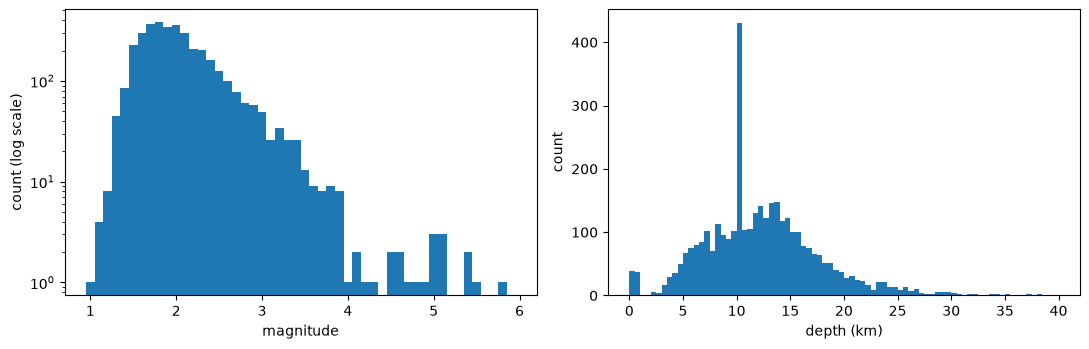

In [27]:
print(eq["출처"].value_counts(), "\n")
print(eq["규모종류"].value_counts(), "\n")
print(eq["깊이"].describe())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
eq["규모"].plot.hist(bins=np.arange(0.95, 6.05, 0.1), ax=ax[0], log=True)
ax[0].set_xlabel("magnitude"); ax[0].set_ylabel("count (log scale)")
eq["깊이"].plot.hist(bins=np.arange(0, 40.5, 0.5), ax=ax[1])
ax[1].set_xlabel("depth (km)"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

In [28]:
# USGS 출처의 데이터만 필터링하여 확인
usgs_eq = eq[eq["출처"] == "USGS"]
display(usgs_eq)

,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
3587,3588,2006-05-02T21:06:43.949Z,3.6,mb,10.0,35.613,128.658,"27 km SE of Daegu, South Korea",USGS
3588,3589,2006-08-12T17:48:01.682Z,3.2,mb,10.0,36.466,128.305,"14 km ENE of Sangju, South Korea",USGS
3589,3590,2006-12-01T21:31:37.455Z,2.9,mb,18.3,33.652,125.969,"55 km WNW of Jeju City, South Korea",USGS
3590,3591,2007-04-17T12:21:30.823Z,3.2,mb,16.6,35.980,128.773,"38 km NE of Daegu, South Korea",USGS
3591,3592,2008-08-20T23:22:20.429Z,3.7,mb,10.0,35.415,127.558,"56 km WNW of Jinju, South Korea",USGS
3592,3593,2009-04-18T05:11:56.032Z,3.0,mb,12.7,35.838,128.374,"9 km NW of Daegu, South Korea",USGS
3593,3594,2010-03-06T20:38:30.027Z,3.5,mb,10.0,34.914,126.568,"20 km NE of Mokpo, South Korea",USGS
3594,3595,2010-10-20T23:49:31.673Z,3.0,mb,20.2,37.473,125.248,"95 km WNW of Incheon, South Korea",USGS
3595,3596,2010-12-11T03:11:38.417Z,2.7,mb,7.7,35.357,129.385,"19 km NE of Busan, South Korea",USGS
3596,3597,2011-06-03T11:43:13.052Z,3.4,mb,10.3,37.371,125.636,"59 km W of Incheon, South Korea",USGS


**B-2. AI에게 정제를 맡겨 보기 (15분).** AI에게 아래처럼 요청하고, 받은 코드를 **고치지 말고** 실행하세요. 결과는 `eq_ai`라는 이름에 담습니다.

> 지진 목록 데이터프레임 `eq`에서 이상치와 중복을 제거하는 pandas 코드를 짜 줘.

그다음 원자료와 비교하고, **지워진 행 중 규모가 큰 5개**를 보세요. 그 행들을 지워도 되나요? 그리고 Part A의 MAD를 `규모` 열에 적용하면 어떻게 되는지도 실행해 보세요.

In [29]:
# 지진 규모(규모) 열에 중앙값과 MAD를 활용한 로버스트 z-점수 적용
median_mag = eq["규모"].median()
mad_mag = (eq["규모"] - median_mag).abs().median()

# 로버스트 z-점수 계산 (표준인자 1.4826 곱하기)
robust_z_mag = (eq["규모"] - median_mag) / (1.4826 * mad_mag)

# |z| > 3인 행을 이상치 후보로 필터링
outliers_mag = eq[robust_z_mag.abs() > 3]

print(f"지진 규모 기준 중앙값: {median_mag}, MAD: {mad_mag}")
print(f"MAD 기준 이상치로 검출된 행 수: {len(outliers_mag)}개\n")
print("--- 검출된 이상치 후보 중 상위 10개 샘플 ---")
display(outliers_mag.sort_values("규모", ascending=False).head(10))

지진 규모 기준 중앙값: 2.0, MAD: 0.30000000000000004
MAD 기준 이상치로 검출된 행 수: 95개

--- 검출된 이상치 후보 중 상위 10개 샘플 ---


,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
1110,1111,2016-09-12 20:32:54,5.8,ML,15.0,35.765,129.188,경북 경주시 남남서쪽 11km 지역,KMA
3622,3623,2017-11-15T05:29:30.437Z,5.5,Mw,10.0,36.024,129.379,"3 km E of Pohang, South Korea",USGS
1844,1845,2017-11-15 14:29:31,5.4,ML,7.0,36.109,129.366,경북 포항시 북북동쪽 10km 지역,KMA
3610,3611,2016-09-12T11:32:55.962Z,5.4,Mw,10.0,35.811,129.066,"15 km WSW of Gyeongju, South Korea",USGS
3609,3610,2016-09-12T10:44:32.967Z,5.1,mb,10.5,35.783,129.186,"9 km SSW of Gyeongju, South Korea",USGS
811,812,2014-04-01 04:48:35,5.1,ML,10.0,36.950,124.500,충남 태안군 서쪽 162km 해역,KMA
1109,1110,2016-09-12 19:44:32,5.1,ML,13.0,35.769,129.190,경북 경주시 남남서쪽 10km 지역,KMA
1078,1079,2016-07-05 20:33:03,5.0,ML,10.0,35.510,129.990,울산 울주군 동쪽 68km 해역,KMA
3603,3604,2014-03-31T19:48:34.009Z,5.0,mb,11.2,36.925,124.573,"155 km W of Taean, South Korea",USGS
3608,3609,2016-07-05T11:33:04.302Z,5.0,mb,8.8,35.517,130.007,"69 km E of Ulsan, South Korea",USGS


In [30]:
# B-2: AI가 준 코드 (결과를 eq_ai 에 담기)
# 완전히 같은 중복 행 제거
eq_ai = eq.drop_duplicates(keep='first').copy()

# 한반도 인근 위경도 및 물리적으로 유효한 깊이, 규모 기준 필터링 (이상치 제거)
eq_ai = eq_ai[
    (eq_ai['위도'].between(30, 45)) &
    (eq_ai['경도'].between(120, 135)) &
    (eq_ai['규모'] > 0) &
    (eq_ai['깊이'] >= 0)
]

report(eq, "원자료")
report(eq_ai, "AI 정제")
removed = eq[~eq["번호"].isin(eq_ai["번호"])]
print("지워진 행:", len(removed))
display(removed.sort_values("규모", ascending=False).head(5))

원자료        행  3641 | 최대 5.8 | M≥5 10개 | M≥4  22개 | b = 0.91 ± 0.02 (n=1516)
AI 정제      행  3617 | 최대 5.8 | M≥5 10개 | M≥4  22개 | b = 0.9 ± 0.02 (n=1506)
지워진 행: 24


,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
434,435,2010-04-07 06:54:24,2.9,ML,NaN,35.755,125.183,전북 부안군 서쪽 140km 해역,KMA
1753,1754,2017-06-25 17:07:15,2.4,ML,NaN,33.511,126.965,제주 제주시 동쪽 40km 해역,KMA
1809,1810,2017-09-14 08:56:20,2.3,ML,NaN,36.799,124.677,충남 태안군 서쪽 144km 해역,KMA
389,390,2009-10-19 20:09:33,2.3,ML,NaN,35.098,126.406,전남 목포시 북쪽 32km 지역,KMA
159,160,2007-08-25 07:21:16,2.2,ML,NaN,37.418,124.846,인천 옹진군 서쪽 129km 해역,KMA


**B-3. 내 정제 (20분).** 한 단계마다 **행 수**를 출력하세요. 자료가 많아 한 줄씩 대조할 수 없을 때 가장 먼저 쓰는 검증입니다. "0개 지웠다"는 결과도 정말 0개여야 하는지 확인합니다.

| 함정 | 이 자료에서 어떻게 확인했나 | 결정 (뺌 · 고침 · 남김) | 근거 (AI 밖의 기준) | 행 수 변화 |
|---|---|---|---|---|
| 출처 혼합 (KMA · USGS) |시간 표기을 통일한 뒤 지진 발생 시간과 경도 위도가 오차범위(시간 3초 이내, 위경도 0.1도 이내) 내에서 겹치는지 확인 | 뺌 | 매우 유사한 발생시간과 발생 위치정보는 같은 지진을 지시함 | -51 |
| 완전히 같은 행 | 발생시각과 규모, 위도 경도, 깊이 정보가 완전히 같으면 확인가능 | 뺌 | 발생시각과 규모, 위도 경도, 깊이 정보가 완전히 같다면 같은 지진이 여러번 기록된 것임 | -15 |
| 발파 | 규모 단위를 통일한 뒤 규모 2.0 이하인 행을 확인 | 뻄 | 규모가 작은 지진들은 발파일 가능성이 있고 b값을 결정하는데 노이즈로 작용할 가능성 존재 | -2118 |
| 큰 지진 (규모 5 이상) | 규모 열이 5 이상인 행 추출하여 확인 | 남김 | 규모가 큰 지진들은 b값을 정하는데 필요함 | 행수 변화 없음 |
| (선택) 시기별 Mc 차이 | | | | |
| (선택) 깊이 10.0 고정값 | | | | |

In [31]:
import pandas as pd
import numpy as np

eq_my = eq.copy()
print(f"시작 행 수: {len(eq_my)}")

# 1. 모든 규모를 ML로 통일
# KMA ML은 유지하고, USGS mb/Mw만 기존 보정식으로 ML로 환산합니다.
def to_ml(row):
    mag = float(row["규모"])
    mag_type = str(row["규모종류"]).strip().upper()

    if row["출처"] == "KMA" or mag_type == "ML":
        return mag
    if mag_type == "MB":
        return round(1.12 * mag - 0.18, 2)
    if mag_type == "MW":
        return round(1.05 * mag - 0.12, 2)
    return mag

eq_my["규모"] = eq_my.apply(to_ml, axis=1)
eq_my["규모종류"] = "ML"

# 2. 발생시각 원본 열을 KST 기준으로 통일
def parse_to_kst(row):
    time_str = str(row["발생시각"]).strip()
    if row["출처"] == "USGS":
        return (
            pd.to_datetime(time_str, utc=True)
            .tz_convert("Asia/Seoul")
            .tz_localize(None)
        )
    return pd.to_datetime(time_str).tz_localize(None)

eq_my["발생시각"] = eq_my.apply(parse_to_kst, axis=1)
print("발생시각 열을 모두 KST 기준으로 통일했습니다.")

# 3. KMA를 기준으로, 네 조건이 모두 일치하는 USGS 중복 행만 찾기
kma_data = eq_my[eq_my["출처"] == "KMA"].copy()
usgs_data = eq_my[eq_my["출처"] == "USGS"].copy()

duplicated_usgs_indices = []
match_records = []

# KMA와 USGS의 기록 방식 차이를 고려한 중복 판정 허용 오차
TIME_TOL_SECONDS = 3
COORD_TOL_DEG = 0.15
ML_TOL = 0.5

for usgs_idx, usgs_row in usgs_data.iterrows():
    time_diff = (kma_data["발생시각"] - usgs_row["발생시각"]).abs()
    lat_diff = (kma_data["위도"] - usgs_row["위도"]).abs()
    lon_diff = (kma_data["경도"] - usgs_row["경도"]).abs()
    ml_diff = (kma_data["규모"] - usgs_row["규모"]).abs()

    candidates = kma_data[
        (time_diff <= pd.Timedelta(seconds=TIME_TOL_SECONDS)) &
        (lat_diff <= COORD_TOL_DEG) &
        (lon_diff <= COORD_TOL_DEG) &
        (ml_diff <= ML_TOL)
    ]

    if not candidates.empty:
        best_idx = time_diff.loc[candidates.index].idxmin()
        best_kma = kma_data.loc[best_idx]
        duplicated_usgs_indices.append(usgs_idx)

        match_records.append({
            "USGS 번호": usgs_row["번호"],
            "KMA 번호": best_kma["번호"],
            "ML 차이": round(abs(usgs_row["규모"] - best_kma["규모"]), 2),
            "시간 차이(초)": round(
                abs((usgs_row["발생시각"] - best_kma["발생시각"]).total_seconds()), 2
            ),
            "위도 차이": round(abs(usgs_row["위도"] - best_kma["위도"]), 3),
            "경도 차이": round(abs(usgs_row["경도"] - best_kma["경도"]), 3),
        })

# 4. 제거 대상은 중복으로 판정된 USGS 행만
eq_my = eq_my.drop(index=duplicated_usgs_indices)

print("모든 행의 규모종류를 ML로 통일했습니다.")
print(f"제거된 USGS 중복 행 수: {len(duplicated_usgs_indices)}")
print(f"중복 제거 후 행 수: {len(eq_my)}")

match_df = pd.DataFrame(match_records)
display(match_df)

report(eq_my, "내 정제")

시작 행 수: 3641
발생시각 열을 모두 KST 기준으로 통일했습니다.
모든 행의 규모종류를 ML로 통일했습니다.
제거된 USGS 중복 행 수: 51
중복 제거 후 행 수: 3590


,USGS 번호,KMA 번호,ML 차이,시간 차이(초),위도 차이,경도 차이
0,3588,34,0.05,1.95,0.071,0.008
1,3589,59,0.10,1.68,0.045,0.036
2,3590,87,0.23,1.46,0.074,0.010
3,3591,117,0.00,0.18,0.037,0.055
4,3592,261,0.04,0.43,0.004,0.012
5,3593,335,0.12,1.03,0.020,0.045
6,3594,427,0.06,1.97,0.037,0.025
7,3595,482,0.32,0.33,0.054,0.036
8,3596,492,0.46,2.58,0.035,0.044
9,3597,538,0.27,1.05,0.027,0.029


내 정제       행  3590 | 최대 5.8 | M≥5  5개 | M≥4  13개 | b = 0.98 ± 0.03 (n=1465)


In [32]:
# 100% 완전히 모든 열의 값이 일치하는 중복 행 검사 및 제거
exact_duplicates_count = eq_my.duplicated().sum()
print(f"완전히 동일한 중복 행 수: {exact_duplicates_count}개")

if exact_duplicates_count > 0:
    eq_my = eq_my.drop_duplicates(keep='first')
    print(f"완전 중복 행 제거 완료. 최종 행 수: {len(eq_my)}")
else:
    print("완전히 동일한 중복 행이 존재하지 않습니다.")

완전히 동일한 중복 행 수: 0개
완전히 동일한 중복 행이 존재하지 않습니다.


**이 방법으로는 지진마다 부여된 고유번호가 다르므로 완전히 같은 데이터 행을 솎아낼 수 없음.**

In [33]:
# 고유 식별자·중간 계산 열을 제외한 실제 관측값으로 완전 중복 검사
exclude_columns = ["번호"]
compare_columns = [
    col for col in eq_my.columns
    if col not in exclude_columns
]

# 같은 출처 내부에서 관측값이 완전히 같은 행을 확인
duplicate_rows = eq_my[
    eq_my.duplicated(subset=compare_columns, keep=False)
].sort_values(compare_columns)

print(f"번호를 제외한 완전 중복 행 수: {len(duplicate_rows)}개")
display(duplicate_rows.head(20))

# 각 중복 묶음에서 첫 행만 남기고 제거
before_count = len(eq_my)
eq_my = eq_my.drop_duplicates(subset=compare_columns, keep="first").copy()

print(f"제거된 완전 중복 행 수: {before_count - len(eq_my)}개")
print(f"완전 중복 제거 후 행 수: {len(eq_my)}")

번호를 제외한 완전 중복 행 수: 30개


,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
563,564,2011-09-23 12:35:16,2.7,ML,12.8,35.153,128.599,경남 창원시 남서쪽 11km 지역,KMA
564,565,2011-09-23 12:35:16,2.7,ML,12.8,35.153,128.599,경남 창원시 남서쪽 11km 지역,KMA
640,641,2012-07-18 14:11:57,2.0,ML,17.1,35.719,128.489,대구 달성군 남동쪽 8km 지역,KMA
641,642,2012-07-18 14:11:57,2.0,ML,17.1,35.719,128.489,대구 달성군 남동쪽 8km 지역,KMA
753,754,2013-08-29 09:13:18,2.5,ML,13.4,35.717,127.940,경남 합천군 북서쪽 26km 지역,KMA
754,755,2013-08-29 09:13:18,2.5,ML,13.4,35.717,127.940,경남 합천군 북서쪽 26km 지역,KMA
889,890,2015-01-14 05:12:57,2.2,ML,7.3,36.048,128.144,경북 김천시 남남동쪽 11km 지역,KMA
890,891,2015-01-14 05:12:57,2.2,ML,7.3,36.048,128.144,경북 김천시 남남동쪽 11km 지역,KMA
1007,1008,2016-02-06 23:13:52,2.1,ML,21.4,37.512,128.293,강원 원주시 동북동쪽 38km 지역,KMA
1008,1009,2016-02-06 23:13:52,2.1,ML,21.4,37.512,128.293,강원 원주시 동북동쪽 38km 지역,KMA


제거된 완전 중복 행 수: 15개
완전 중복 제거 후 행 수: 3575


In [34]:
# ML로 통일된 '규모'가 2.0 이하인 행을 제거하고, 제거 대상 전체를 확인
before_count = len(eq_my)

removed_low_ml = eq_my[eq_my["규모"] <= 2.0].copy()
eq_my = eq_my[eq_my["규모"] > 2.0].copy()

print("[ML 규모 2.0 이하 제거 결과]")
print(f"- 제거 전 행 수: {before_count}개")
print(f"- 제거된 행 수: {len(removed_low_ml)}개")
print(f"- 제거 후 행 수: {len(eq_my)}개")

print("\n--- 제거된 ML 규모 2.0 이하 행 전체 ---")
display(
    removed_low_ml.sort_values(["규모", "발생시각"])[
        ["번호", "발생시각", "규모", "규모종류", "깊이", "위도", "경도", "위치", "출처"]
    ]
)

report(eq_my, "내 정제")

[ML 규모 2.0 이하 제거 결과]
- 제거 전 행 수: 3575개
- 제거된 행 수: 2118개
- 제거 후 행 수: 1457개

--- 제거된 ML 규모 2.0 이하 행 전체 ---


,번호,발생시각,규모,규모종류,깊이,위도,경도,위치,출처
2751,2752,2021-03-04 10:10:48,1.0,ML,10.0,38.168,129.627,강원도 강릉시 북동쪽 80km 해역,KMA
1031,1032,2016-04-07 02:15:10,1.1,ML,17.7,37.129,128.115,충북 충주시 북동쪽 23km 지역,KMA
2577,2578,2020-03-26 21:16:42,1.1,ML,7.2,35.652,128.106,경남 합천군 북북서쪽 11km 지역,KMA
2857,2858,2021-11-25 18:27:01,1.1,ML,11.4,33.644,127.039,제주 제주시 동북동쪽 50km 해역,KMA
3419,3420,2025-01-31 16:14:53,1.1,ML,13.0,35.593,130.052,울산 울주군 동쪽 73km 해역,KMA
...,...,...,...,...,...,...,...,...,...
3555,3556,2025-10-22 05:03:58,2.0,ML,12.0,37.372,127.128,경기 화성시 북동쪽 32km 지역,KMA
3558,3559,2025-10-30 14:03:43,2.0,ML,10.0,34.214,128.162,전남 여수시 남동쪽 76km 해역,KMA
3561,3562,2025-11-02 08:19:51,2.0,ML,11.9,34.280,126.238,전남 해남군 남서쪽 46km 해역,KMA
3562,3563,2025-11-05 03:29:25,2.0,ML,9.3,36.304,128.944,경북 안동시 남남동쪽 35km 지역,KMA


내 정제       행  1457 | 최대 5.8 | M≥5  5개 | M≥4  13개 | b = 0.98 ± 0.03 (n=1457)


In [35]:
# ML 규모 5.0 이상 지진을 확인만 하고, 데이터에서는 제거하지 않음
strong_earthquakes = eq_my[
    eq_my["규모"] >= 5.0
].sort_values("발생시각")

print(f"ML 규모 5.0 이상 지진 수: {len(strong_earthquakes)}개")

display(
    strong_earthquakes[
        ["번호", "발생시각", "위도", "경도", "규모", "규모종류", "위치", "출처"]
    ]
)

# 규모 5 이상 지진도 포함한 최종 정제 결과
report(eq_my, "내 정제")

ML 규모 5.0 이상 지진 수: 5개


,번호,발생시각,위도,경도,규모,규모종류,위치,출처
811,812,2014-04-01 04:48:35,36.950,124.500,5.1,ML,충남 태안군 서쪽 162km 해역,KMA
1078,1079,2016-07-05 20:33:03,35.510,129.990,5.0,ML,울산 울주군 동쪽 68km 해역,KMA
1109,1110,2016-09-12 19:44:32,35.769,129.190,5.1,ML,경북 경주시 남남서쪽 10km 지역,KMA
1110,1111,2016-09-12 20:32:54,35.765,129.188,5.8,ML,경북 경주시 남남서쪽 11km 지역,KMA
1844,1845,2017-11-15 14:29:31,36.109,129.366,5.4,ML,경북 포항시 북북동쪽 10km 지역,KMA


내 정제       행  1457 | 최대 5.8 | M≥5  5개 | M≥4  13개 | b = 0.98 ± 0.03 (n=1457)


**B-4. 비교와 결론 (10분).** 세 줄(원자료 · AI 정제 · 내 정제)을 나란히 놓고, 보조 ②의 틀로 결론을 쓰세요.

> 〔어느 자료·기간·지역〕에서 〔무엇을〕 보니 〔수치와 방향〕이었다. 이는 〔지질학적 해석〕으로 설명할 수 있다. 다만 〔한계〕 때문에 〔여기까지〕만 말할 수 있다.

**결론:** 2006년부터 2025년까지의 한국 지역 지진에 대한 KMA 와 USGS 의 자료에서 발생한 지진 내역과 그 규모들을 보니 규모 5.0 이상 지진이 5번 있었고 b value 가 0.98 ± 0.03 (n=1457) 로 측정되었다. 이처럼 b값이 약 1이라는 결과는 규모가 한 단계 커질수록 지진 발생 빈도가 대체로 약 10분의 1로 감소하는 Gutenberg–Richter 관계와 부합한다. 다만 이 자료는 USGS–KMA 중복 판정 기준과 규모 환산 방식에 따라 규모 5 이상 개수와 b값이 달라질 수 있으므로 실제 한반도 지진활동 전체로 일반화할 수는 없다.

**Part A에서는 MAD가 답이었는데, 지진 규모에는 왜 답이 아닌가? (한두 문장):** 사암 밀도에서 나타난 매우 큰 값은 물리적으로 불가능하여 단위 오류나 측정 오류일 가능성이 높지만, 지진 규모 분포는 큰 값이 드물게 나타나는 것이 실제 자연현상이므로 MAD로 큰 지진을 이상치로 제거하면 규모 5 이상 지진 수와 b값을 왜곡하게 된다.

In [36]:
# 위도, 경도, 발생시각이 모두 완전히 일치하는 중복 행 검사 및 제거
dup_columns = ['위도', '경도', '발생시각']
exact_geo_time_duplicates = eq_my.duplicated(subset=dup_columns).sum()
print(f"위도, 경도, 발생시각이 완전히 일치하는 중복 행 수: {exact_geo_time_duplicates}개")

if exact_geo_time_duplicates > 0:
    eq_my = eq_my.drop_duplicates(subset=dup_columns, keep='first')
    print(f"중복 행 제거 완료. 최종 행 수: {len(eq_my)}")
else:
    print("해당 열 조합을 기준으로 하는 중복 행이 존재하지 않습니다.")

# 최종 정제 상태 리포트
report(eq_my, "내 정제")

위도, 경도, 발생시각이 완전히 일치하는 중복 행 수: 0개
해당 열 조합을 기준으로 하는 중복 행이 존재하지 않습니다.
내 정제       행  1457 | 최대 5.8 | M≥5  5개 | M≥4  13개 | b = 0.98 ± 0.03 (n=1457)


In [37]:
report(eq, "원자료")
report(eq_ai, "AI 정제")
report(eq_my, "내 정제")

원자료        행  3641 | 최대 5.8 | M≥5 10개 | M≥4  22개 | b = 0.91 ± 0.02 (n=1516)
AI 정제      행  3617 | 최대 5.8 | M≥5 10개 | M≥4  22개 | b = 0.9 ± 0.02 (n=1506)
내 정제       행  1457 | 최대 5.8 | M≥5  5개 | M≥4  13개 | b = 0.98 ± 0.03 (n=1457)


**B-5. 질문이 바뀌면? (두세 줄)** 질문을 "한반도 지진의 **깊이 분포**는 지역마다 다른가?"로 바꾸면, B-3 결정표에서 무엇이 달라지나요? 한 가지 이상.

**답:** 히스토그램을 통해 지진데이터에서 깊이가 매우 많이 10km 로 적혀있는 데이터가 압도적으로 많음을 확인하였으므로 이를 제거하거나 추가적인 자료 확인이 필요하다. 또한 발파와 얕은 인공지진은 깊이를 왜곡할 수 있으므로 발생 위치와 깊이를 같이 확인해 제거해야 한다.

## AI 활용 기록지 (5칸) — 최소 2건 (A-1, B-2 포함)

| # | ① 도구·모델 | ② 프롬프트 원문 | ③ AI 산출물 (셀 번호·요약) | ④ 검증 — 무엇을 보고 확인했나 | ⑤ 수정 — 무엇을 왜 바꿨나 |
|---|---|---|---|---|---|
| 1 | gemini 3.5 flash | "완전히 똑같은 행을 제거하는 코드를 짜줘."  | cell23 | 제거된 행이 0개 임에서 이상함을 확인 | 모든 열이 동일한 행은 행에 고유번호가 매겨져 있기에 존재할 수 없으므로 이를 고려하지 않고 동일한 행을 제거하는 코드로 변경. |
| 2 | gemini 3.5 flash | "usgs 와 kma 에 공통적으로 존재하는 행을 제거하는 코드를 짜줘." | cell22 | 처음엔 이상함을 느끼지 못했으나 최종적으로 규모가 5 이상인 지진을 출력할 때 같은 지진이 usgs 와 kma 두 개의 기관에서 나타나는 것이 5쌍 존재함을 확인| 다른 두 기관에서 같은 지진 데이터를 기록한 것의 여부를 판볋할 때 규모 0.2 이하인 것으로 규정했으나 이 범위를 벗어나는 같은 지진이 존재함을 확인하고 0.5 의 규모 차이로 문턱값을 높임.  |

**④칸 예시 — 지난주 토론 결과지에서 뽑았습니다.** "몇 개를 뽑아 직접 계산해 보고 정제 전과 비교한다" · "규모 1–2 지진이 1년에 몇백 회라면 20년이면 몇천 회 — 결과가 이보다 크게 벗어나면 의심한다" · "원자료의 최댓값·최솟값을 벗어난 값이 나오면 검토한다". **"AI에게 다시 물어봤다"는 검증이 아닙니다.**